# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duaf9877/FlyRank-AI-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/duaf9877/FlyRank-AI-ML-Internship/main/data/raw/content_refresh_anonymized.csv"
)

df["target"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Dataset shape:", df.shape)
print("Clients:", df["client_id"].nunique())

Dataset shape: (30000, 45)
Clients: 32


In [3]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_since_last_update",
    "content_age_days",
    "avg_position",
    "ctr",
    "engagement_rate",
    "content_type",
    "main_intent",
    "provider_used"
]

X = df[features]
y = df["target"]
groups = df["client_id"]

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of model features:", len(features))

Number of model features: 19


In [4]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(
    df.iloc[train_idx]["client_id"]
)

test_clients = set(
    df.iloc[test_idx]["client_id"]
)

assert len(
    train_clients.intersection(test_clients)
) == 0

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Overlapping clients:", 0)

Train rows: 23837
Test rows: 6163
Overlapping clients: 0


In [5]:
preprocess = ColumnTransformer([
    (
        "num",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]),
        numeric_features
    ),

    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]),
        categorical_features
    )
])

model = Pipeline([
    ("preprocess", preprocess),

    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [6]:
queue = df.iloc[test_idx].copy()

queue["decline_probability"] = (
    model.predict_proba(X_test)[:, 1]
)

queue["predicted_declining"] = (
    model.predict(X_test)
)

queue[
    [
        "content_id",
        "decline_probability",
        "predicted_declining"
    ]
].head()

,content_id,decline_probability,predicted_declining
0,content_304f48230142,0.562424,1
1,content_a1fb4e703a9e,0.431337,0
5,content_d4084a4bc775,0.629258,1
13,content_a5a2fbc76336,0.644705,1
19,content_af865035b328,0.580027,1


In [7]:
# Normalize value signals safely.

def min_max(series):

    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        series - minimum
    ) / (
        maximum - minimum
    )

In [8]:
queue["click_value"] = min_max(
    queue["clicks_90d"]
)

queue["impression_value"] = min_max(
    queue["impressions_90d"]
)

queue["session_value"] = min_max(
    queue["sessions_90d"]
)

queue["business_value_score"] = (
    0.4 * queue["click_value"]
    +
    0.3 * queue["impression_value"]
    +
    0.3 * queue["session_value"]
)

In [9]:
# Priority combines measured decline probability
# with an operational value signal.

queue["priority_score"] = (
    0.7 * queue["decline_probability"]
    +
    0.3 * queue["business_value_score"]
)

queue[
    [
        "decline_probability",
        "business_value_score",
        "priority_score"
    ]
].describe()

,decline_probability,business_value_score,priority_score
count,6163.000000,6163.000000,6163.000000
mean,0.536298,0.006635,0.377399
std,0.123678,0.027106,0.084900
min,0.006027,0.000000,0.155239
25%,0.421910,0.000226,0.297911
50%,0.569881,0.001018,0.400243
75%,0.648802,0.003853,0.454940
max,0.773177,0.791079,0.544459


In [10]:
ctr_threshold = queue["ctr"].median()
engagement_threshold = (
    queue["engagement_rate"].median()
)

stale_threshold = (
    queue["days_since_last_update"].quantile(0.75)
)

high_value_threshold = (
    queue["business_value_score"].quantile(0.75)
)

In [11]:
def assign_archetype(row):

    high_risk = (
        row["decline_probability"] >= 0.50
    )

    high_value = (
        row["business_value_score"]
        >= high_value_threshold
    )

    stale = (
        row["days_since_last_update"]
        >= stale_threshold
    )

    low_ctr = (
        row["ctr"] < ctr_threshold
    )

    low_engagement = (
        row["engagement_rate"]
        < engagement_threshold
    )

    if high_risk and high_value:
        return "high_risk_high_value"

    elif high_risk and stale:
        return "stale_high_risk"

    elif high_risk and low_ctr:
        return "high_risk_ctr_opportunity"

    elif high_risk and low_engagement:
        return "high_risk_engagement_opportunity"

    elif high_value:
        return "high_value_monitor"

    else:
        return "low_priority"

In [12]:
queue["archetype"] = queue.apply(
    assign_archetype,
    axis=1
)

queue["archetype"].value_counts()

archetype
low_priority                 2192
high_risk_ctr_opportunity    1560
high_value_monitor            960
stale_high_risk               870
high_risk_high_value          581
Name: count, dtype: int64

In [13]:
action_map = {

    "high_risk_high_value":
        "Priority human review",

    "stale_high_risk":
        "Review and refresh content",

    "high_risk_ctr_opportunity":
        "Review title and snippet opportunity",

    "high_risk_engagement_opportunity":
        "Review content usefulness",

    "high_value_monitor":
        "Monitor performance",

    "low_priority":
        "No immediate action"
}

queue["recommended_action"] = (
    queue["archetype"]
    .map(action_map)
)

In [14]:
def create_reason_codes(row):

    reasons = []

    if row["decline_probability"] >= 0.70:
        reasons.append("high_decline_risk")

    elif row["decline_probability"] >= 0.50:
        reasons.append("elevated_decline_risk")

    if (
        row["business_value_score"]
        >= high_value_threshold
    ):
        reasons.append("high_value_page")

    if (
        row["days_since_last_update"]
        >= stale_threshold
    ):
        reasons.append("content_stale")

    if row["ctr"] < ctr_threshold:
        reasons.append("below_typical_ctr")

    if (
        row["engagement_rate"]
        < engagement_threshold
    ):
        reasons.append("below_typical_engagement")

    if len(reasons) == 0:
        reasons.append("monitor")

    return " | ".join(reasons)

In [15]:
queue["reason_codes"] = queue.apply(
    create_reason_codes,
    axis=1
)

In [16]:
queue = queue.sort_values(
    "priority_score",
    ascending=False
)

queue["rank"] = range(
    1,
    len(queue) + 1
)

display_columns = [
    "rank",
    "content_id",
    "priority_score",
    "decline_probability",
    "business_value_score",
    "archetype",
    "recommended_action",
    "reason_codes"
]

queue[
    display_columns
].head(20)

,rank,content_id,priority_score,decline_probability,business_value_score,archetype,recommended_action,reason_codes
10870,1,content_a5dbb404bdc2,0.544459,0.750850,0.062881,high_risk_high_value,Priority human review,high_decline_risk | high_value_page | content_...
22197,2,content_6ac3ab740bbf,0.542937,0.765421,0.023808,high_risk_high_value,Priority human review,high_decline_risk | high_value_page | content_...
18063,3,content_b08562686d22,0.541928,0.772890,0.003016,stale_high_risk,Review and refresh content,high_decline_risk | content_stale
22204,4,content_ef9bdd92b523,0.541225,0.773177,0.000003,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...
27709,5,content_84c5f6af423c,0.541026,0.772892,0.000004,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...
7026,6,content_829c68e60d13,0.540278,0.771584,0.000564,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...
27993,7,content_26d48a980581,0.537392,0.767058,0.001506,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...
12439,8,content_624b2fd8dca5,0.537378,0.767351,0.000775,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...
14347,9,content_c8300a2e0cfa,0.536791,0.766833,0.000027,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...
938,10,content_4d6923d17c10,0.536563,0.766432,0.000201,stale_high_risk,Review and refresh content,high_decline_risk | content_stale | below_typi...


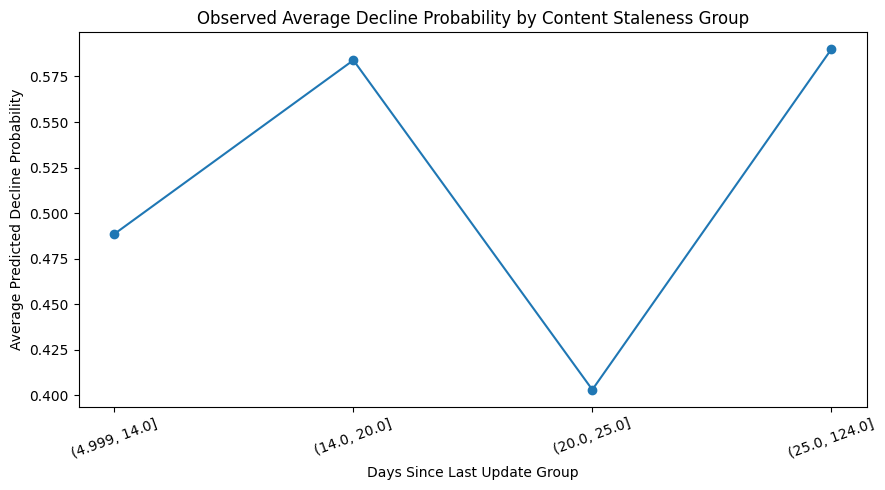

In [17]:
decay_summary = (
    queue
    .assign(
        age_group=pd.qcut(
            queue["days_since_last_update"],
            q=4,
            duplicates="drop"
        )
    )
    .groupby(
        "age_group",
        observed=True
    )["decline_probability"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.plot(
    decay_summary["age_group"].astype(str),
    decay_summary["decline_probability"],
    marker="o"
)

plt.title(
    "Observed Average Decline Probability by Content Staleness Group"
)

plt.xlabel(
    "Days Since Last Update Group"
)

plt.ylabel(
    "Average Predicted Decline Probability"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This playbook is intended for a content or SEO team reviewing a limited amount of work.

The ranked queue can help answer:

Which pages may deserve review first?
Which pages combine measured decline risk with higher value?
What observable signals explain the recommendation?
Which type of review may be appropriate?

The queue is a decision-support tool. It helps prioritize human attention.

Limits

This system does not:

prove that a page will decline;
prove that a specific action will improve rankings;
identify a causal reason for a decline;
predict Google's algorithm;
automatically change, publish, delete, or redirect content;
replace professional editorial, SEO, legal, or business judgment.

The model's results were measured on the available anonymized dataset and should not automatically be generalized to every future client or environment.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Whether the page is still strategically important.
Whether the observed decline is recent or part of normal variation.
Whether the page has an obvious technical or indexing problem.
Whether search intent may have changed.
Whether refreshing the content could create business, legal, or brand risk.
Whether a content change would overlap with or cannibalize another page.
Whether the recommendation is based on enough useful evidence.

A high priority score means review sooner, not change automatically.

No-go list — what should NOT be automated

The following actions should not be automated from this model output:

publishing or rewriting content;
deleting content;
changing URLs;
creating redirects;
changing canonical tags;
making indexing decisions;
making legal, medical, financial, or compliance-sensitive claims;
changing a page solely because the model gives a high score;
interpreting model probability as certainty;
treating reason codes as proven causal explanations.

The model can prioritize review. A human must decide what action, if any, is appropriate.

Cost and value thinking

Not every recommendation has the same value or implementation cost.

A practical review queue should consider:

Risk: how strongly the model prioritizes the page.
Value: current traffic and visibility signals.
Cost: the estimated effort required to investigate and act.

For example:

Action	Typical cost	Potential value
Monitor	Low	Preserves human attention
Title/snippet review	Low	Possible CTR improvement
Content refresh	Medium	Potential relevance improvement
Major content rewrite	High	Higher potential but higher cost
Technical investigation	Medium/High	Important when technical causes exist

The current notebook uses available value signals as a simple proxy. It does not estimate financial return or guarantee that an action will create value.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring approach

This notebook is a non-production prototype, so monitoring is light and based on practical triggers.

The recommendations should be reviewed or retrained when evidence suggests that the model or data environment has changed.

Suggested triggers

Retrain or investigate when:

Data drift: important feature distributions change substantially.
Prediction drift: the distribution of decline probabilities changes unexpectedly.
Performance decline: newly labeled review data shows materially weaker precision, recall, or F1.
Base-rate change: the proportion of declining pages changes materially.
Feature availability changes: important inputs become missing or unreliable.
Business workflow changes: the queue is being used for a different type of client or content.
Periodic review: re-evaluate on a planned schedule when new data is available.

These are triggers for investigation, not automatic retraining commands.

In [18]:
monitoring_baseline = {

    "positive_class_rate":
        float(y_test.mean()),

    "mean_decline_probability":
        float(
            queue["decline_probability"].mean()
        ),

    "median_decline_probability":
        float(
            queue["decline_probability"].median()
        ),

    "mean_ctr":
        float(queue["ctr"].mean()),

    "mean_engagement_rate":
        float(
            queue["engagement_rate"].mean()
        )
}

monitoring_baseline

{'positive_class_rate': 0.5109524582184002,
 'mean_decline_probability': 0.5362977883831462,
 'median_decline_probability': 0.569880674436406,
 'mean_ctr': 0.2900681486289145,
 'mean_engagement_rate': 2.911687489858835}

In [19]:
os.makedirs(
    "work/outputs",
    exist_ok=True
)

with open(
    "work/outputs/monitoring_baseline.json",
    "w"
) as file:

    json.dump(
        monitoring_baseline,
        file,
        indent=2
    )

print(
    "Saved monitoring baseline."
)

Saved monitoring baseline.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [20]:
os.makedirs(
    "work/outputs",
    exist_ok=True
)

os.makedirs(
    "work/figures",
    exist_ok=True
)

In [21]:
export_columns = [
    "rank",
    "content_id",
    "priority_score",
    "decline_probability",
    "business_value_score",
    "archetype",
    "recommended_action",
    "reason_codes",
    "content_type",
    "main_intent",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "engagement_rate"
]

ranked_queue = (
    queue[export_columns]
    .copy()
)

ranked_queue.to_csv(
    "work/outputs/ranked_action_queue.csv",
    index=False
)

print(
    "Exported ranked_action_queue.csv"
)

print(
    "Queue shape:",
    ranked_queue.shape
)

Exported ranked_action_queue.csv
Queue shape: (6163, 15)


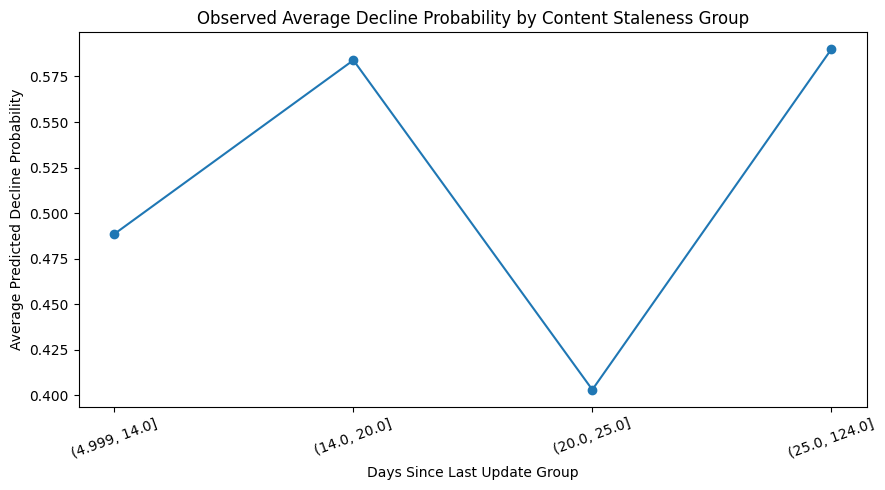

Saved figure to work/figures/


In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    decay_summary["age_group"].astype(str),
    decay_summary["decline_probability"],
    marker="o"
)

plt.title(
    "Observed Average Decline Probability by Content Staleness Group"
)

plt.xlabel(
    "Days Since Last Update Group"
)

plt.ylabel(
    "Average Predicted Decline Probability"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "work/figures/decay_refresh_insight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved figure to work/figures/"
)

In [23]:
action_summary = (
    ranked_queue["recommended_action"]
    .value_counts()
    .reset_index()
)

action_summary.columns = [
    "recommended_action",
    "count"
]

action_summary

,recommended_action,count
0,No immediate action,2192
1,Review title and snippet opportunity,1560
2,Monitor performance,960
3,Review and refresh content,870
4,Priority human review,581


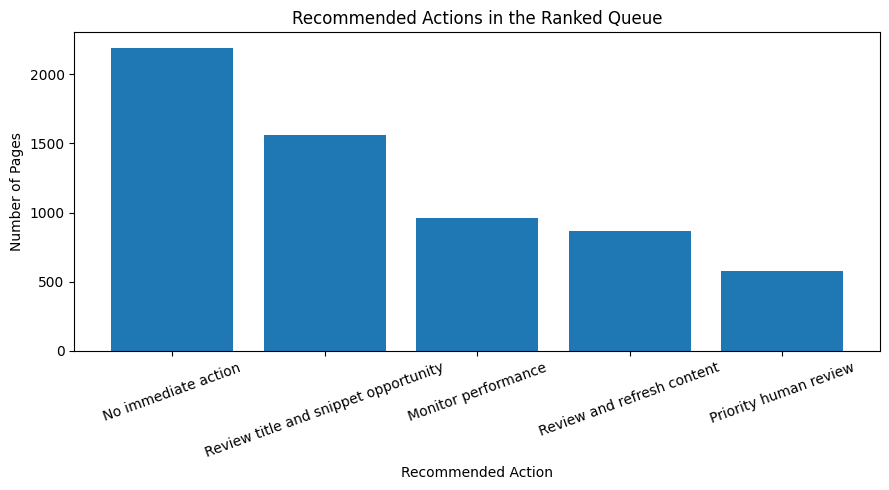

In [24]:
plt.figure(figsize=(9, 5))

plt.bar(
    action_summary["recommended_action"],
    action_summary["count"]
)

plt.title(
    "Recommended Actions in the Ranked Queue"
)

plt.xlabel(
    "Recommended Action"
)

plt.ylabel(
    "Number of Pages"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "work/figures/action_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.